In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("default")

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent

SUMMARY_PATH = PROJECT_ROOT / "results" / "architecture_results" / "summary.csv"
summary = pd.read_csv(SUMMARY_PATH)

metric_cols = [
    "loss",
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
]
higher_is_better = {metric: metric != "loss" for metric in metric_cols}
summary["dataset_size"] = summary["total_size"].astype(int)
summary = summary.sort_values(["dataset_name", "method"]).reset_index(drop=True)

print(f"Loaded {len(summary)} rows from {SUMMARY_PATH}")
display(summary.head())



Loaded 36 rows from /Users/roman/Desktop/НИР/FUTURE/results/architecture_results/summary.csv


,method,dataset_name,train_size,test_size,total_size,channels,time_steps,num_classes,loss,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,dataset_size
0,GAF,ECG5000,500,4500,5000,1,140,5,0.3127,0.9378,0.5559,0.6886,0.5559,0.5983,0.9293,0.9378,0.9312,5000
1,MTF,ECG5000,500,4500,5000,1,140,5,0.3256,0.9158,0.5554,0.5371,0.5554,0.5397,0.9253,0.9158,0.9199,5000
2,STFT,ECG5000,500,4500,5000,1,140,5,0.3486,0.9316,0.5649,0.6208,0.5649,0.5746,0.9254,0.9316,0.9273,5000
3,raw,ECG5000,500,4500,5000,1,140,5,0.2655,0.9396,0.5680,0.8077,0.5680,0.5965,0.9338,0.9396,0.9338,5000
4,raw_GAF,ECG5000,500,4500,5000,1,140,5,0.3550,0.9313,0.5607,0.6819,0.5607,0.5816,0.9243,0.9313,0.9262,5000


In [3]:
def best_rows_by_metric(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    rows = []
    for dataset_name, dataset_df in df.groupby("dataset_name", sort=True):
        dataset_size = int(dataset_df["total_size"].iloc[0])
        for metric in metrics:
            idx = dataset_df[metric].idxmax() if higher_is_better[metric] else dataset_df[metric].idxmin()
            best = dataset_df.loc[idx]
            rows.append(
                {
                    "dataset_name": dataset_name,
                    "dataset_size": dataset_size,
                    "metric": metric,
                    "best_method": best["method"],
                    "best_value": best[metric],
                }
            )
    return pd.DataFrame(rows)

best_by_metric = best_rows_by_metric(summary, metric_cols)

best_by_metric_style = (
    best_by_metric
    .style
    .format({"best_value": "{:.4f}"})
    .set_caption("Best method for each dataset and metric")
)
display(best_by_metric_style)


,dataset_name,dataset_size,metric,best_method,best_value
0,ECG5000,5000,loss,raw,0.2655
1,ECG5000,5000,accuracy,stats,0.9447
2,ECG5000,5000,balanced_accuracy,raw,0.5680
3,ECG5000,5000,macro_precision,raw,0.8077
4,ECG5000,5000,macro_recall,raw,0.5680
5,ECG5000,5000,macro_f1,GAF,0.5983
6,ECG5000,5000,weighted_precision,raw,0.9338
7,ECG5000,5000,weighted_recall,stats,0.9447
8,ECG5000,5000,weighted_f1,stats,0.9360
9,FacesUCR,2250,loss,STFT,0.4966


Best combinations by macro_f1:


,dataset_name,dataset_size,method,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,ECG5000,5000,GAF,0.3127,0.9378,0.5559,0.5983,0.9312
15,FacesUCR,2250,raw_STFT,0.4993,0.8956,0.8463,0.8497,0.8933
26,MedicalImages,1141,stats,0.6762,0.7724,0.7397,0.7295,0.7656
35,SwedishLeaf,1125,stats,0.2063,0.9328,0.9351,0.9323,0.9317


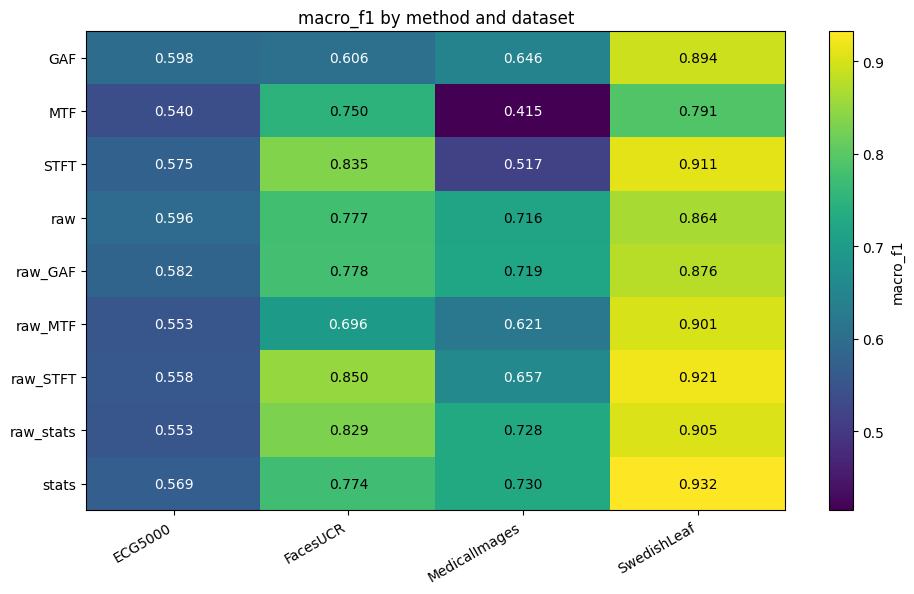

In [4]:
primary_metric = "macro_f1"

primary_pivot = summary.pivot(index="method", columns="dataset_name", values=primary_metric)
primary_best = summary.loc[summary.groupby("dataset_name")[primary_metric].idxmax()].sort_values("dataset_name")

print(f"Best combinations by {primary_metric}:")
display(
    primary_best[
        [
            "dataset_name",
            "dataset_size",
            "method",
            "loss",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
        ]
    ].style.format(
        {
            "loss": "{:.4f}",
            "accuracy": "{:.4f}",
            "balanced_accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "weighted_f1": "{:.4f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(1.2 * primary_pivot.shape[1] + 5, 0.45 * primary_pivot.shape[0] + 2))
im = ax.imshow(primary_pivot, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(primary_pivot.shape[1]), labels=primary_pivot.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(primary_pivot.shape[0]), labels=primary_pivot.index)
ax.set_title(f"{primary_metric} by method and dataset")

for i in range(primary_pivot.shape[0]):
    for j in range(primary_pivot.shape[1]):
        value = primary_pivot.iloc[i, j]
        ax.text(j, i, f"{value:.3f}", ha="center", va="center", color="white" if value < primary_pivot.max().max() * 0.75 else "black")

fig.colorbar(im, ax=ax, label=primary_metric)
plt.tight_layout()
plt.show()


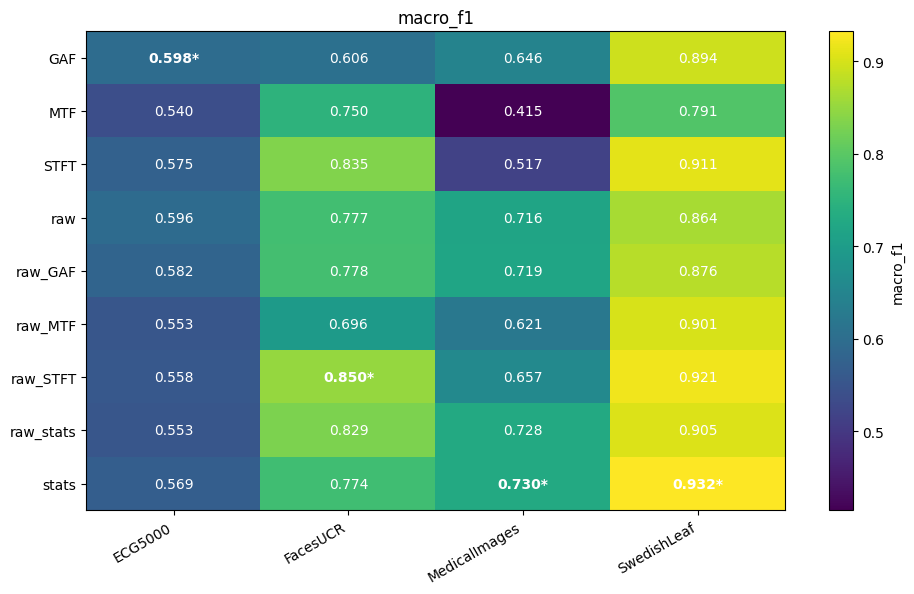

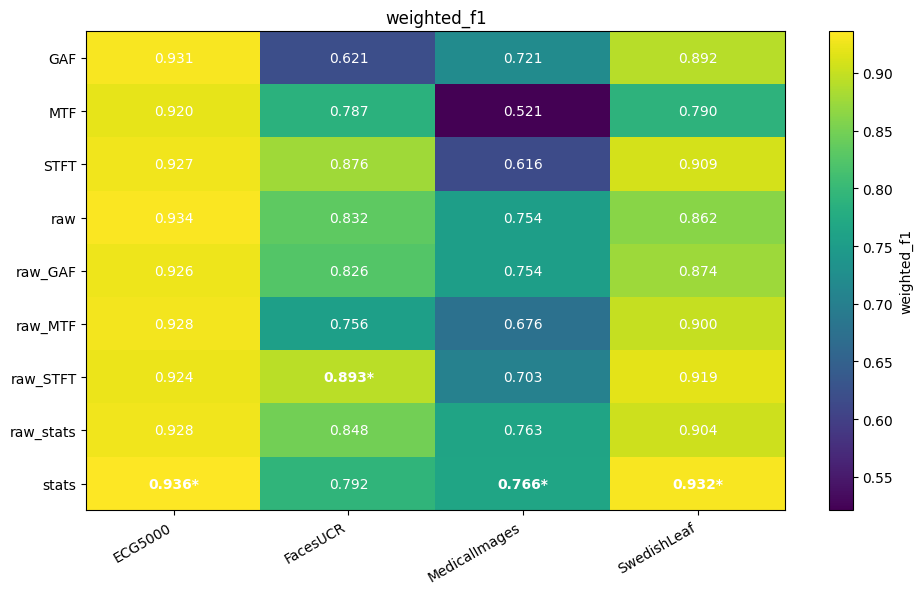

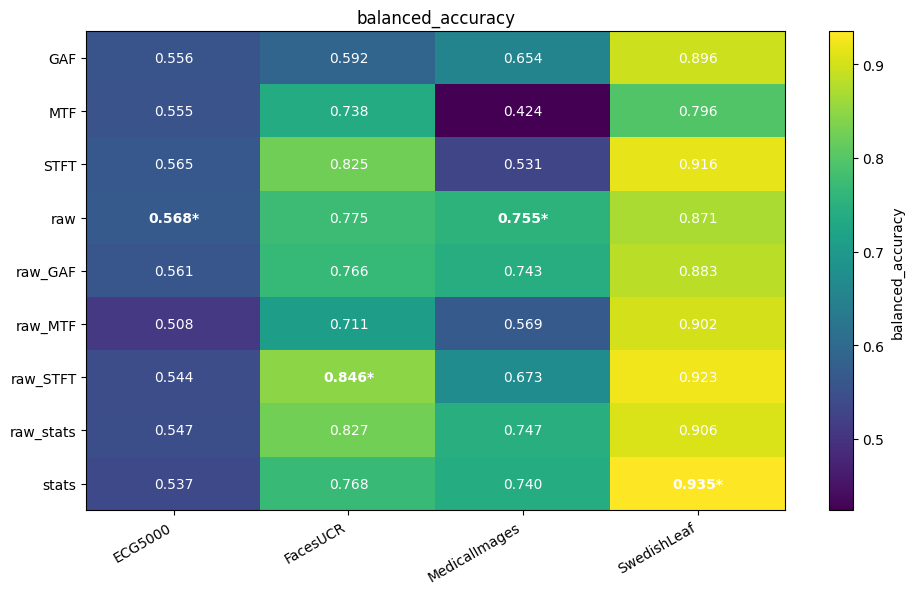

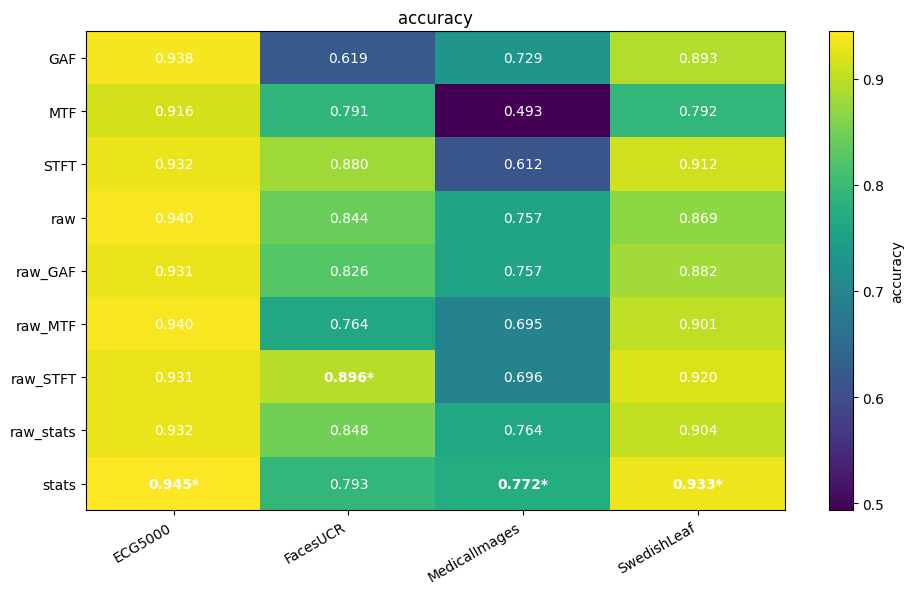

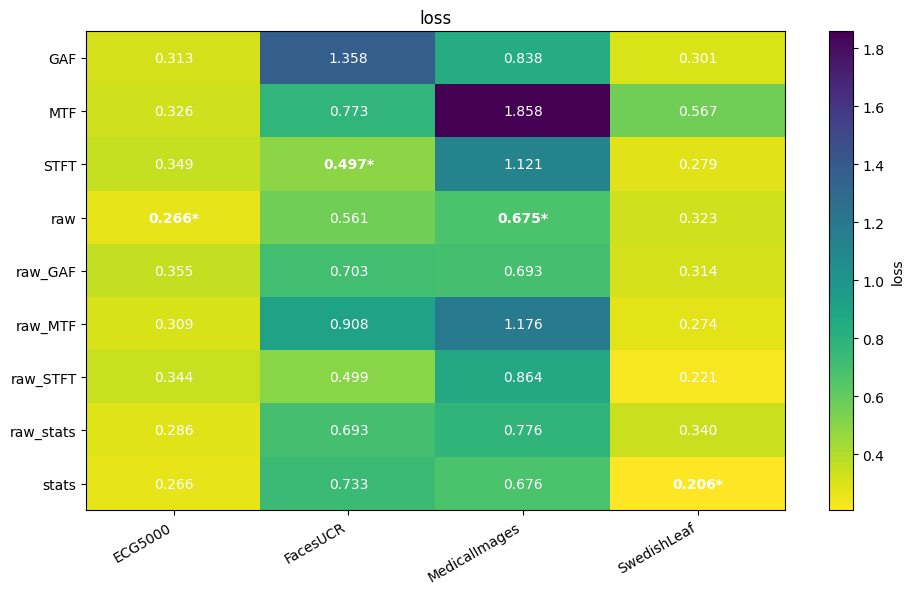

In [5]:
def plot_metric_heatmap(metric: str, *, cmap: str | None = None) -> None:
    pivot = summary.pivot(index="method", columns="dataset_name", values=metric)
    best_idx = pivot.idxmin(axis=0) if not higher_is_better[metric] else pivot.idxmax(axis=0)
    cmap = cmap or ("viridis" if higher_is_better[metric] else "viridis_r")

    fig, ax = plt.subplots(figsize=(1.2 * pivot.shape[1] + 5, 0.45 * pivot.shape[0] + 2))
    im = ax.imshow(pivot, aspect="auto", cmap=cmap)
    ax.set_xticks(np.arange(pivot.shape[1]), labels=pivot.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(pivot.shape[0]), labels=pivot.index)
    ax.set_title(metric)

    for i, method in enumerate(pivot.index):
        for j, dataset_name in enumerate(pivot.columns):
            value = pivot.loc[method, dataset_name]
            is_best = method == best_idx[dataset_name]
            label = f"{value:.3f}" + ("*" if is_best else "")
            ax.text(j, i, label, ha="center", va="center", color="white", fontweight="bold" if is_best else "normal")

    fig.colorbar(im, ax=ax, label=metric)
    plt.tight_layout()
    plt.show()

for metric in ["macro_f1", "weighted_f1", "balanced_accuracy", "accuracy", "loss"]:
    plot_metric_heatmap(metric)


In [6]:
def add_metric_ranks(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    ranked = df.copy()
    rank_cols = []
    for metric in metrics:
        rank_col = f"rank_{metric}"
        ranked[rank_col] = ranked.groupby("dataset_name")[metric].rank(
            ascending=not higher_is_better[metric],
            method="min",
        )
        rank_cols.append(rank_col)
    ranked["mean_rank"] = ranked[rank_cols].mean(axis=1)
    ranked["is_best_macro_f1"] = ranked["rank_macro_f1"].eq(1)
    return ranked

ranked_summary = add_metric_ranks(summary, metric_cols)
method_rating = (
    ranked_summary
    .groupby("method", as_index=False)
    .agg(
        mean_rank=("mean_rank", "mean"),
        median_rank=("mean_rank", "median"),
        wins_macro_f1=("is_best_macro_f1", "sum"),
        mean_macro_f1=("macro_f1", "mean"),
        mean_weighted_f1=("weighted_f1", "mean"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        mean_accuracy=("accuracy", "mean"),
        mean_loss=("loss", "mean"),
    )
    .sort_values(["mean_rank", "mean_macro_f1"], ascending=[True, False])
    .reset_index(drop=True)
)

print("Overall method rating: lower mean_rank is better")
display(
    method_rating.style.format(
        {
            "mean_rank": "{:.2f}",
            "median_rank": "{:.2f}",
            "mean_macro_f1": "{:.4f}",
            "mean_weighted_f1": "{:.4f}",
            "mean_balanced_accuracy": "{:.4f}",
            "mean_accuracy": "{:.4f}",
            "mean_loss": "{:.4f}",
        }
    ).background_gradient(subset=["mean_rank"], cmap="viridis_r")
)


Overall method rating: lower mean_rank is better


,method,mean_rank,median_rank,wins_macro_f1,mean_macro_f1,mean_weighted_f1,mean_balanced_accuracy,mean_accuracy,mean_loss
0,stats,3.19,2.83,2,0.7512,0.8563,0.7450,0.8606,0.4704
1,raw,3.89,3.11,0,0.7383,0.8455,0.7422,0.8522,0.4563
2,raw_stats,3.97,3.89,0,0.7538,0.8607,0.7569,0.8621,0.5238
3,raw_STFT,4.03,3.78,1,0.7465,0.8597,0.7467,0.8606,0.4821
4,STFT,4.53,4.06,0,0.7092,0.8322,0.7094,0.8338,0.5613
5,raw_GAF,5.19,5.39,0,0.7387,0.8452,0.7382,0.8490,0.5163
6,raw_MTF,5.92,5.67,0,0.6931,0.8150,0.6724,0.8249,0.6671
7,GAF,6.14,6.00,1,0.6860,0.7913,0.6745,0.7946,0.7025
8,MTF,8.08,8.22,0,0.6239,0.7545,0.6284,0.7480,0.8809


In [7]:
comparison_metric = "macro_f1"
baseline_method = "raw"

baseline = summary.loc[summary["method"] == baseline_method, ["dataset_name", comparison_metric]].rename(
    columns={comparison_metric: f"{baseline_method}_{comparison_metric}"}
)
comparison = summary.merge(baseline, on="dataset_name", how="left")
comparison[f"delta_vs_{baseline_method}"] = comparison[comparison_metric] - comparison[f"{baseline_method}_{comparison_metric}"]
comparison = comparison.sort_values(["dataset_name", f"delta_vs_{baseline_method}"], ascending=[True, False])

print(f"Delta in {comparison_metric} versus {baseline_method} baseline")
display(
    comparison[
        [
            "dataset_name",
            "dataset_size",
            "method",
            comparison_metric,
            f"{baseline_method}_{comparison_metric}",
            f"delta_vs_{baseline_method}",
        ]
    ].style.format(
        {
            comparison_metric: "{:.4f}",
            f"{baseline_method}_{comparison_metric}": "{:.4f}",
            f"delta_vs_{baseline_method}": "{:+.4f}",
        }
    ).background_gradient(subset=[f"delta_vs_{baseline_method}"], cmap="RdYlGn")
)


Delta in macro_f1 versus raw baseline


,dataset_name,dataset_size,method,macro_f1,raw_macro_f1,delta_vs_raw
0,ECG5000,5000,GAF,0.5983,0.5965,+0.0019
3,ECG5000,5000,raw,0.5965,0.5965,+0.0000
4,ECG5000,5000,raw_GAF,0.5816,0.5965,-0.0149
2,ECG5000,5000,STFT,0.5746,0.5965,-0.0219
8,ECG5000,5000,stats,0.5691,0.5965,-0.0273
6,ECG5000,5000,raw_STFT,0.5579,0.5965,-0.0386
5,ECG5000,5000,raw_MTF,0.5534,0.5965,-0.0431
7,ECG5000,5000,raw_stats,0.5528,0.5965,-0.0436
1,ECG5000,5000,MTF,0.5397,0.5965,-0.0568
15,FacesUCR,2250,raw_STFT,0.8497,0.7765,+0.0732


## Representation Concat Experiments

Results for the additional concat models:

- `raw_stats_STFT`
- `raw_stats_GAF`
- `raw_stats_GAF_STFT`
- `raw_stats_GAF_MTF_STFT`

This block also isolates the effect of adding `MTF` to `raw_stats_GAF_STFT`.

In [8]:
REPRESENTATION_RESULTS_DIR = PROJECT_ROOT / "results" / "representation_concat_results"
REPRESENTATION_SUMMARY_PATH = REPRESENTATION_RESULTS_DIR / "summary.csv"
MTF_COMPARISON_PATH = REPRESENTATION_RESULTS_DIR / "mtf_comparison.csv"

if REPRESENTATION_SUMMARY_PATH.exists():
    representation_summary = pd.read_csv(REPRESENTATION_SUMMARY_PATH)
    representation_summary["dataset_size"] = representation_summary["total_size"].astype(int)
    representation_summary = representation_summary.sort_values(["dataset_name", "method"]).reset_index(drop=True)
    print(f"Loaded {len(representation_summary)} rows from {REPRESENTATION_SUMMARY_PATH}")
    display(representation_summary)
else:
    representation_summary = pd.DataFrame()
    print(f"No representation concat summary found: {REPRESENTATION_SUMMARY_PATH}")


Loaded 16 rows from /Users/roman/Desktop/НИР/FUTURE/results/representation_concat_results/summary.csv


,method,dataset_name,train_size,test_size,total_size,channels,time_steps,num_classes,loss,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,dataset_size
0,raw_stats_GAF,ECG5000,500,4500,5000,1,140,5,0.2766,0.9384,0.5276,0.6149,0.5276,0.5527,0.9276,0.9384,0.9310,5000
1,raw_stats_GAF_MTF_STFT,ECG5000,500,4500,5000,1,140,5,0.3527,0.9384,0.5290,0.7610,0.5290,0.5773,0.9278,0.9384,0.9254,5000
2,raw_stats_GAF_STFT,ECG5000,500,4500,5000,1,140,5,0.3539,0.9358,0.5412,0.6090,0.5412,0.5639,0.9263,0.9358,0.9301,5000
3,raw_stats_STFT,ECG5000,500,4500,5000,1,140,5,0.3539,0.9287,0.5359,0.6269,0.5359,0.5392,0.9220,0.9287,0.9211,5000
4,raw_stats_GAF,FacesUCR,200,2050,2250,1,131,14,0.9273,0.8254,0.7955,0.8382,0.7955,0.8095,0.8361,0.8254,0.8265,2250
5,raw_stats_GAF_MTF_STFT,FacesUCR,200,2050,2250,1,131,14,0.8405,0.8376,0.8269,0.8390,0.8269,0.8268,0.8482,0.8376,0.8366,2250
6,raw_stats_GAF_STFT,FacesUCR,200,2050,2250,1,131,14,0.9294,0.8302,0.8196,0.8254,0.8196,0.8064,0.8620,0.8302,0.8338,2250
7,raw_stats_STFT,FacesUCR,200,2050,2250,1,131,14,0.6785,0.8805,0.8522,0.8755,0.8522,0.8567,0.8883,0.8805,0.8791,2250
8,raw_stats_GAF,MedicalImages,381,760,1141,1,99,10,0.9638,0.7711,0.7756,0.7567,0.7756,0.7519,0.7886,0.7711,0.7702,1141
9,raw_stats_GAF_MTF_STFT,MedicalImages,381,760,1141,1,99,10,1.1198,0.7618,0.7437,0.7463,0.7437,0.7324,0.7774,0.7618,0.7636,1141


Best new concat model by macro_f1:


,dataset_name,dataset_size,method,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
1,ECG5000,5000,raw_stats_GAF_MTF_STFT,0.3527,0.9384,0.5290,0.5773,0.9254
7,FacesUCR,2250,raw_stats_STFT,0.6785,0.8805,0.8522,0.8567,0.8791
8,MedicalImages,1141,raw_stats_GAF,0.9638,0.7711,0.7756,0.7519,0.7702
13,SwedishLeaf,1125,raw_stats_GAF_MTF_STFT,0.2820,0.9296,0.9324,0.9301,0.9280


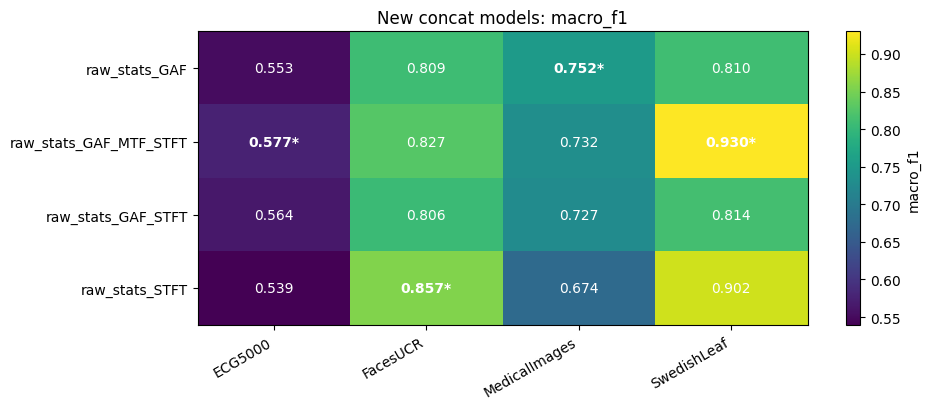

In [9]:
if not representation_summary.empty:
    rep_primary_metric = "macro_f1"
    rep_best = (
        representation_summary
        .loc[representation_summary.groupby("dataset_name")[rep_primary_metric].idxmax()]
        .sort_values("dataset_name")
    )

    print(f"Best new concat model by {rep_primary_metric}:")
    display(
        rep_best[
            [
                "dataset_name",
                "dataset_size",
                "method",
                "loss",
                "accuracy",
                "balanced_accuracy",
                "macro_f1",
                "weighted_f1",
            ]
        ].style.format(
            {
                "loss": "{:.4f}",
                "accuracy": "{:.4f}",
                "balanced_accuracy": "{:.4f}",
                "macro_f1": "{:.4f}",
                "weighted_f1": "{:.4f}",
            }
        )
    )

    rep_pivot = representation_summary.pivot(index="method", columns="dataset_name", values=rep_primary_metric)
    fig, ax = plt.subplots(figsize=(1.2 * rep_pivot.shape[1] + 5, 0.55 * rep_pivot.shape[0] + 2))
    im = ax.imshow(rep_pivot, aspect="auto", cmap="viridis")
    ax.set_xticks(np.arange(rep_pivot.shape[1]), labels=rep_pivot.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(rep_pivot.shape[0]), labels=rep_pivot.index)
    ax.set_title(f"New concat models: {rep_primary_metric}")

    best_idx = rep_pivot.idxmax(axis=0)
    for i, method in enumerate(rep_pivot.index):
        for j, dataset_name in enumerate(rep_pivot.columns):
            value = rep_pivot.loc[method, dataset_name]
            is_best = method == best_idx[dataset_name]
            ax.text(
                j,
                i,
                f"{value:.3f}" + ("*" if is_best else ""),
                ha="center",
                va="center",
                color="white",
                fontweight="bold" if is_best else "normal",
            )

    fig.colorbar(im, ax=ax, label=rep_primary_metric)
    plt.tight_layout()
    plt.show()
else:
    print("Run experiments/representation_concat_evaluating.py first to build this section.")


In [10]:
def rank_representation_methods(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    ranked = df.copy()
    rank_cols = []
    for metric in metrics:
        rank_col = f"rank_{metric}"
        ranked[rank_col] = ranked.groupby("dataset_name")[metric].rank(
            ascending=not higher_is_better[metric],
            method="min",
        )
        rank_cols.append(rank_col)
    ranked["mean_rank"] = ranked[rank_cols].mean(axis=1)
    ranked["is_best_macro_f1"] = ranked["rank_macro_f1"].eq(1)
    return ranked

if not representation_summary.empty:
    rep_ranked = rank_representation_methods(representation_summary, metric_cols)
    rep_method_rating = (
        rep_ranked
        .groupby("method", as_index=False)
        .agg(
            mean_rank=("mean_rank", "mean"),
            wins_macro_f1=("is_best_macro_f1", "sum"),
            mean_macro_f1=("macro_f1", "mean"),
            mean_weighted_f1=("weighted_f1", "mean"),
            mean_balanced_accuracy=("balanced_accuracy", "mean"),
            mean_accuracy=("accuracy", "mean"),
            mean_loss=("loss", "mean"),
        )
        .sort_values(["mean_rank", "mean_macro_f1"], ascending=[True, False])
        .reset_index(drop=True)
    )

    print("New concat method rating: lower mean_rank is better")
    display(
        rep_method_rating.style.format(
            {
                "mean_rank": "{:.2f}",
                "mean_macro_f1": "{:.4f}",
                "mean_weighted_f1": "{:.4f}",
                "mean_balanced_accuracy": "{:.4f}",
                "mean_accuracy": "{:.4f}",
                "mean_loss": "{:.4f}",
            }
        ).background_gradient(subset=["mean_rank"], cmap="viridis_r")
    )


New concat method rating: lower mean_rank is better


,method,mean_rank,wins_macro_f1,mean_macro_f1,mean_weighted_f1,mean_balanced_accuracy,mean_accuracy,mean_loss
0,raw_stats_GAF_MTF_STFT,1.89,2,0.7667,0.8634,0.7580,0.8669,0.6488
1,raw_stats_STFT,2.56,1,0.7429,0.8623,0.7470,0.8681,0.6081
2,raw_stats_GAF,2.67,1,0.7310,0.8332,0.7324,0.8401,0.6780
3,raw_stats_GAF_STFT,2.83,0,0.7278,0.8365,0.7242,0.8415,0.7256


Effect of adding MTF: raw_stats_GAF_STFT -> raw_stats_GAF_MTF_STFT


,dataset_name,dataset_size,delta_loss,delta_accuracy,delta_balanced_accuracy,delta_macro_f1,delta_weighted_f1
0,ECG5000,5000,-0.0011,+0.0027,-0.0122,+0.0134,-0.0047
1,FacesUCR,2250,-0.0890,+0.0073,+0.0073,+0.0204,+0.0029
2,MedicalImages,1141,+0.1235,-0.0079,+0.0407,+0.0052,-0.0056
3,SwedishLeaf,1125,-0.3406,+0.0992,+0.0992,+0.1163,+0.1152


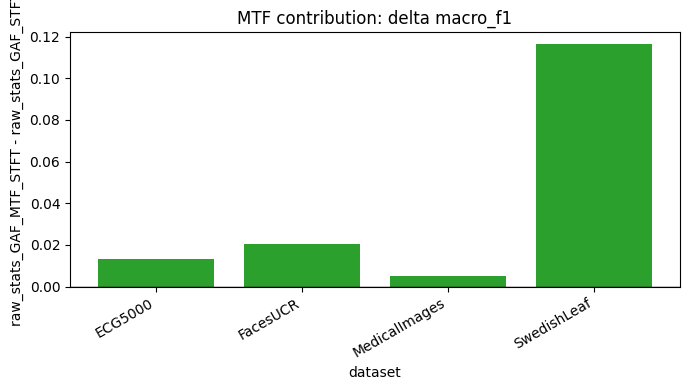

In [11]:
if MTF_COMPARISON_PATH.exists():
    mtf_comparison = pd.read_csv(MTF_COMPARISON_PATH)
    delta_cols = [col for col in mtf_comparison.columns if col.startswith("delta_")]

    print("Effect of adding MTF: raw_stats_GAF_STFT -> raw_stats_GAF_MTF_STFT")
    display(
        mtf_comparison[
            [
                "dataset_name",
                "dataset_size",
                "delta_loss",
                "delta_accuracy",
                "delta_balanced_accuracy",
                "delta_macro_f1",
                "delta_weighted_f1",
            ]
        ].style.format(
            {
                "delta_loss": "{:+.4f}",
                "delta_accuracy": "{:+.4f}",
                "delta_balanced_accuracy": "{:+.4f}",
                "delta_macro_f1": "{:+.4f}",
                "delta_weighted_f1": "{:+.4f}",
            }
        ).background_gradient(subset=["delta_macro_f1", "delta_weighted_f1", "delta_accuracy"], cmap="RdYlGn")
    )

    fig, ax = plt.subplots(figsize=(max(7, 1.4 * len(mtf_comparison)), 4))
    ax.bar(mtf_comparison["dataset_name"], mtf_comparison["delta_macro_f1"], color=np.where(mtf_comparison["delta_macro_f1"] >= 0, "tab:green", "tab:red"))
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("MTF contribution: delta macro_f1")
    ax.set_ylabel("raw_stats_GAF_MTF_STFT - raw_stats_GAF_STFT")
    ax.set_xlabel("dataset")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    mtf_comparison = pd.DataFrame()
    print(f"No MTF comparison found: {MTF_COMPARISON_PATH}")


Best method overall after adding representation concat experiments:


,dataset_name,dataset_size,experiment_group,method,macro_f1,weighted_f1,balanced_accuracy,accuracy,loss
0,ECG5000,5000,architecture,GAF,0.5983,0.9312,0.5559,0.9378,0.3127
43,FacesUCR,2250,representation_concat,raw_stats_STFT,0.8567,0.8791,0.8522,0.8805,0.6785
44,MedicalImages,1141,representation_concat,raw_stats_GAF,0.7519,0.7702,0.7756,0.7711,0.9638
35,SwedishLeaf,1125,architecture,stats,0.9323,0.9317,0.9351,0.9328,0.2063


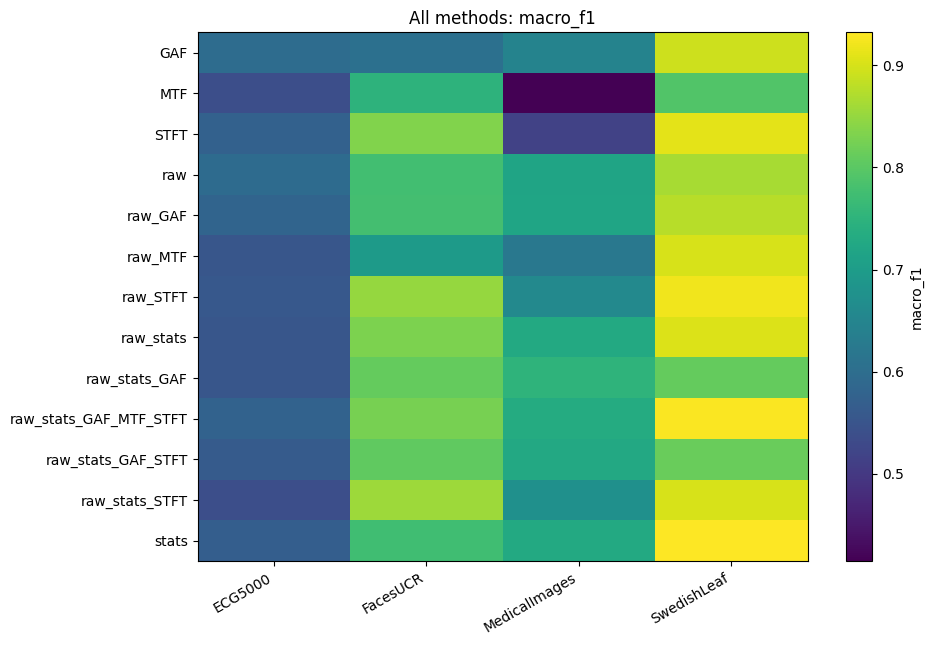

In [12]:
if not representation_summary.empty:
    combined_summary = pd.concat(
        [
            summary.assign(experiment_group="architecture"),
            representation_summary.assign(experiment_group="representation_concat"),
        ],
        ignore_index=True,
    )

    combined_best = (
        combined_summary
        .loc[combined_summary.groupby("dataset_name")["macro_f1"].idxmax()]
        .sort_values("dataset_name")
    )

    print("Best method overall after adding representation concat experiments:")
    display(
        combined_best[
            [
                "dataset_name",
                "dataset_size",
                "experiment_group",
                "method",
                "macro_f1",
                "weighted_f1",
                "balanced_accuracy",
                "accuracy",
                "loss",
            ]
        ].style.format(
            {
                "macro_f1": "{:.4f}",
                "weighted_f1": "{:.4f}",
                "balanced_accuracy": "{:.4f}",
                "accuracy": "{:.4f}",
                "loss": "{:.4f}",
            }
        )
    )

    combined_pivot = combined_summary.pivot_table(index="method", columns="dataset_name", values="macro_f1", aggfunc="max")
    fig, ax = plt.subplots(figsize=(1.2 * combined_pivot.shape[1] + 5, 0.35 * combined_pivot.shape[0] + 2))
    im = ax.imshow(combined_pivot, aspect="auto", cmap="viridis")
    ax.set_xticks(np.arange(combined_pivot.shape[1]), labels=combined_pivot.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(combined_pivot.shape[0]), labels=combined_pivot.index)
    ax.set_title("All methods: macro_f1")
    fig.colorbar(im, ax=ax, label="macro_f1")
    plt.tight_layout()
    plt.show()


По текущим экспериментам видно, что concat fusion пока не дает универсального выигрыша на всех датасетах. Лучшие результаты часто достигаются отдельными модальностями: stats стабильно сильны на ECG5000, MedicalImages и особенно SwedishLeaf, а raw лучше проявляется по balanced/macro-метрикам на части датасетов. Единственный явно сильный пример полезного fusion — FacesUCR, где связка raw + STFT стала лучшей почти по всем метрикам.

- statistical features — сейчас самая стабильная модальность;
- STFT — самая перспективная image-модальность;
- GAF может быть полезен для macro F1 / сложных классов;
- MTF пока не показал явной пользы;
- concat fusion работает, но только когда модальности действительно дополняют друг друга.

# 3x Concat